In [35]:
! pip install pycaret

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

| Feature    | Description                                                      |
|------------|------------------------------------------------------------------|
| DEPTH      | Depth at which measurements are taken (meters or feet).          |
| GR         | Gamma Ray - natural radioactivity, identifies lithology/shale.   |
| RHOB       | Bulk Density - density of rock formation.                        |
| Vp         | P-wave Velocity - speed of compressional seismic waves.         |
| Vsh        | Shale Volume - estimated fraction of shale in the formation.    |
| Caliper    | Borehole diameter measurement to detect washouts.               |
| Porosity   | Percentage of pore space in the rock.                            |
| Resistivity| Electrical resistivity indicating fluid type and saturation.    |
| Stress     | In-situ rock stress for wellbore stability and fracture prediction. |
| PP         | Pore Pressure - pressure within the pore spaces of the rock.    |


In [37]:
well1= pd.read_csv('/content/well 1.csv')
well2= pd.read_csv('/content/well 2.csv')
well3= pd.read_csv('/content/well 3.csv')
well4= pd.read_csv('/content/well 4.csv')
well5= pd.read_csv('/content/well 5.csv')
well6= pd.read_csv('/content/well 6.csv')
well7= pd.read_csv('/content/well 7.csv')
well8= pd.read_csv('/content/well 8.csv')

In [38]:
df=pd.concat([well1, well2, well3, well4, well5, well6, well7, well8], ignore_index=True)

df.head()

,DEPTH,GR,RHOB,Vp,Vsh,Caliper,Porosity,Resistivity,Stress,PP
0,22.0024,57.3820,1.4506,1.4614,0.033808,11.4844,66.1596,0.7881,312783.4781,1609.0
1,22.1548,58.0070,1.4506,1.4594,0.044766,11.4844,66.1591,0.7751,314949.9782,1609.0
2,22.3072,59.1046,1.4506,1.4577,0.064012,11.4844,66.1585,0.7798,317116.4783,1609.0
3,22.4596,59.2124,1.4506,1.4567,0.065902,11.4844,66.1581,0.7711,319282.9784,1609.0
4,22.6120,59.8294,1.4506,1.4564,0.076721,11.4844,66.1575,0.7446,321449.4786,1609.0


In [39]:
df.shape

(11494, 10)

In [40]:
df.isnull().sum()

,0
DEPTH,0
GR,0
RHOB,0
Vp,0
Vsh,0
Caliper,0
Porosity,0
Resistivity,0
Stress,0
PP,0


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11494 entries, 0 to 11493
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DEPTH        11494 non-null  float64
 1   GR           11494 non-null  float64
 2   RHOB         11494 non-null  float64
 3   Vp           11494 non-null  float64
 4   Vsh          11494 non-null  float64
 5   Caliper      11494 non-null  float64
 6   Porosity     11494 non-null  float64
 7   Resistivity  11494 non-null  float64
 8   Stress       11494 non-null  float64
 9   PP           11494 non-null  float64
dtypes: float64(10)
memory usage: 898.1 KB


In [42]:
df.describe()

,DEPTH,GR,RHOB,Vp,Vsh,Caliper,Porosity,Resistivity,Stress,PP
count,11494.000000,11494.000000,11494.000000,11494.000000,11494.000000,11494.000000,11494.000000,11494.000000,1.149400e+04,11494.000000
mean,139.708824,92.087422,1.805392,-25.703265,0.661127,10.091069,59.443962,0.987094,2.535401e+06,1840.075003
std,74.660054,8.951782,0.135371,162.894928,0.451688,0.632879,6.693833,0.266715,1.450494e+06,219.426644
min,5.948800,42.267500,1.082400,-999.250000,-0.162116,9.415300,41.174600,0.357000,6.647748e+04,1416.000000
25%,78.177400,87.600575,1.737000,1.511500,0.575324,9.777000,54.937325,0.839525,1.376452e+06,1668.000000
50%,132.923800,92.628000,1.816700,1.537000,0.672497,9.967150,58.791100,0.951200,2.353846e+06,1823.000000
75%,191.025100,97.888425,1.900200,1.580200,0.757985,10.245500,63.029525,1.090200,3.424687e+06,2006.000000
max,335.882800,114.995600,2.117400,1.724800,46.208200,16.375000,98.848500,2.869200,6.932513e+06,2314.000000


In [43]:
def cap_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[column] = data[column].clip(lower=lower_bound, upper=upper_bound)
    return data

df = cap_outliers_iqr(df, 'Vp')
df = cap_outliers_iqr(df, 'Vsh')

df = cap_outliers_iqr(df, 'Caliper')

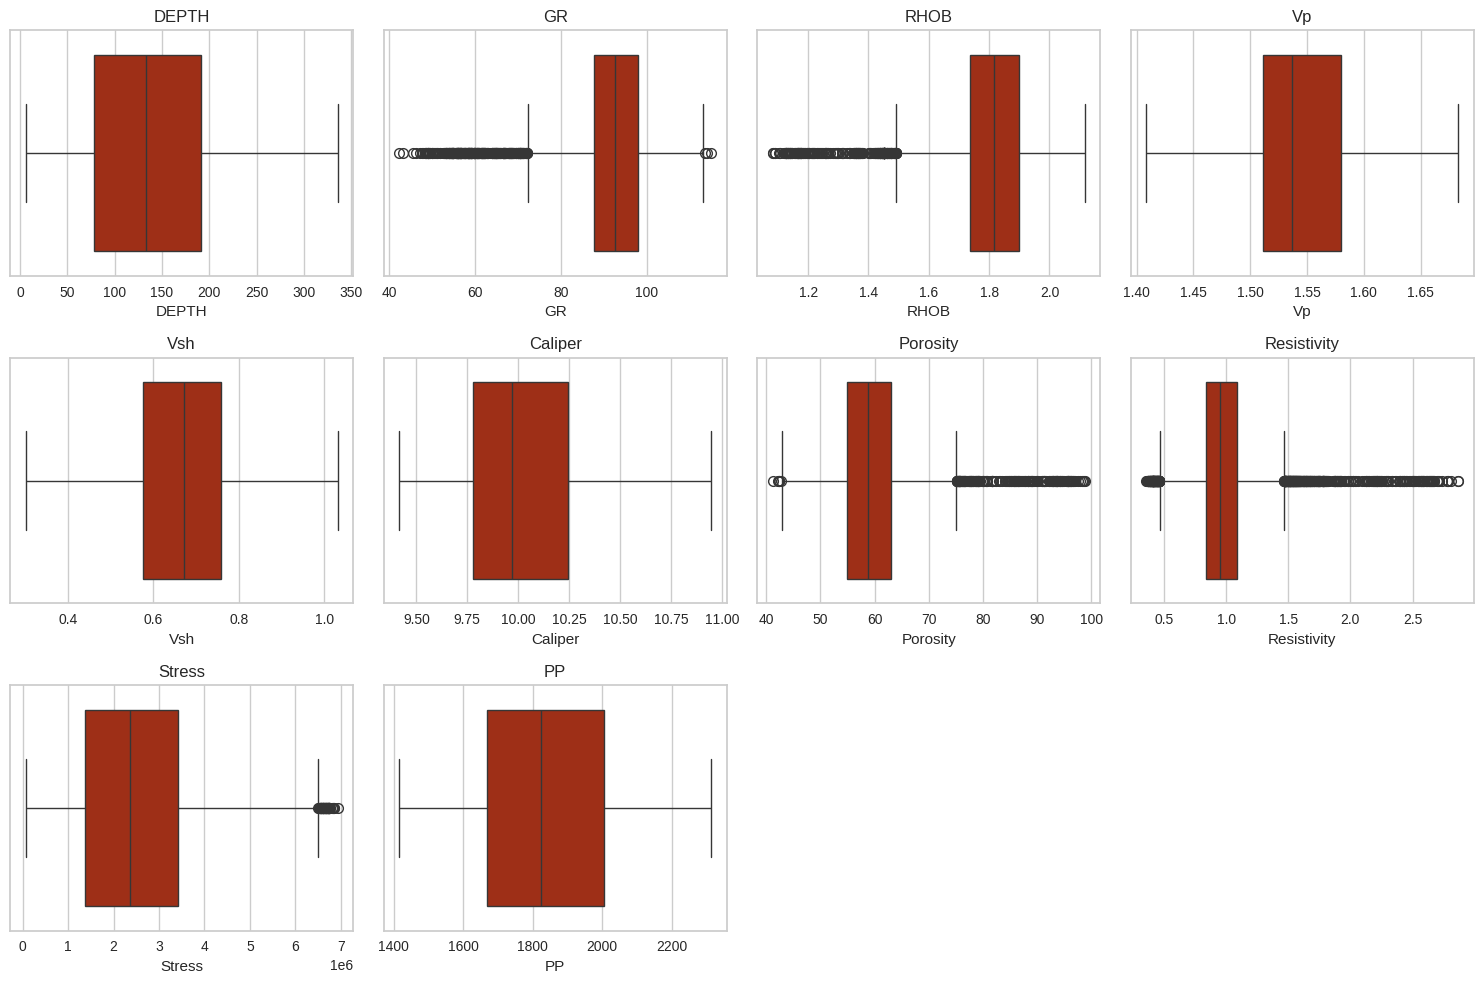

In [44]:
numeric_cols = df.select_dtypes(include='number').columns

# Set up the matplotlib figure size
plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(x=df[col],palette="gnuplot")
    plt.title(col)
    plt.tight_layout()

plt.show()

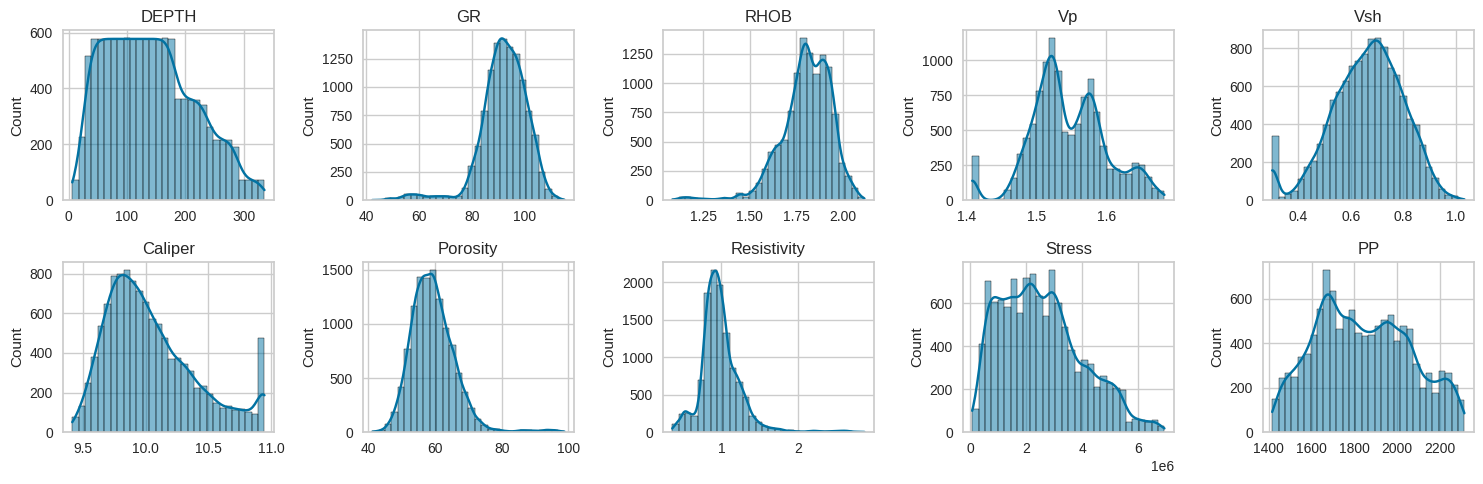

In [45]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(df.columns, 1):
    plt.subplot(2, 5, i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)
    plt.xlabel('')
plt.tight_layout()
plt.show()

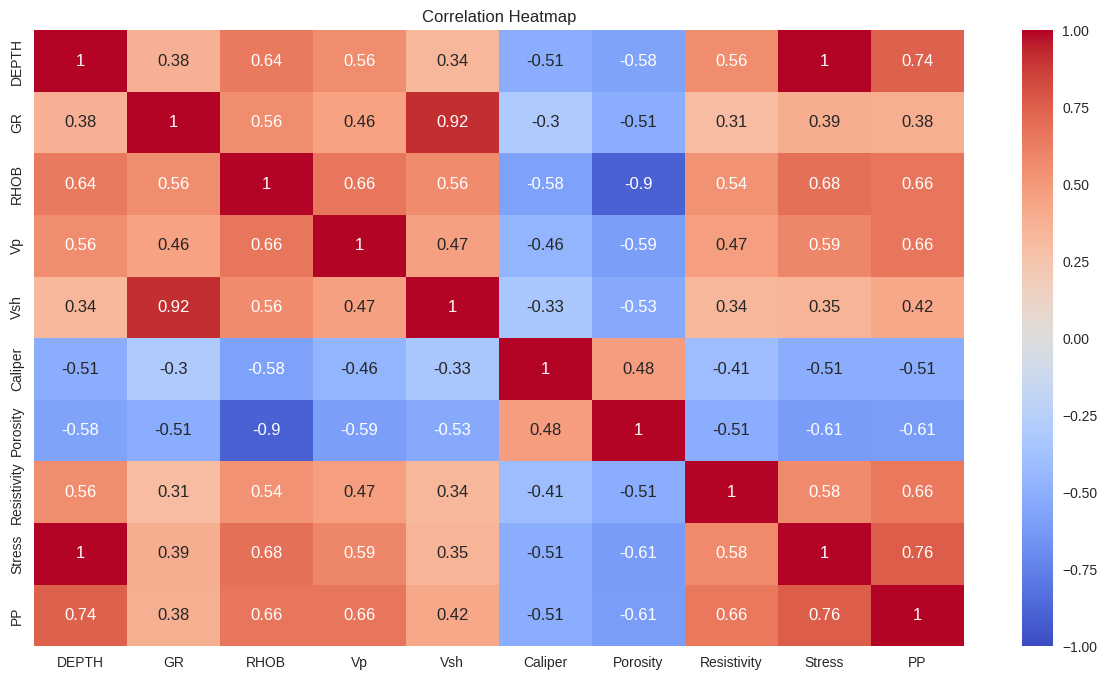

In [46]:
plt.figure(figsize=(15, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

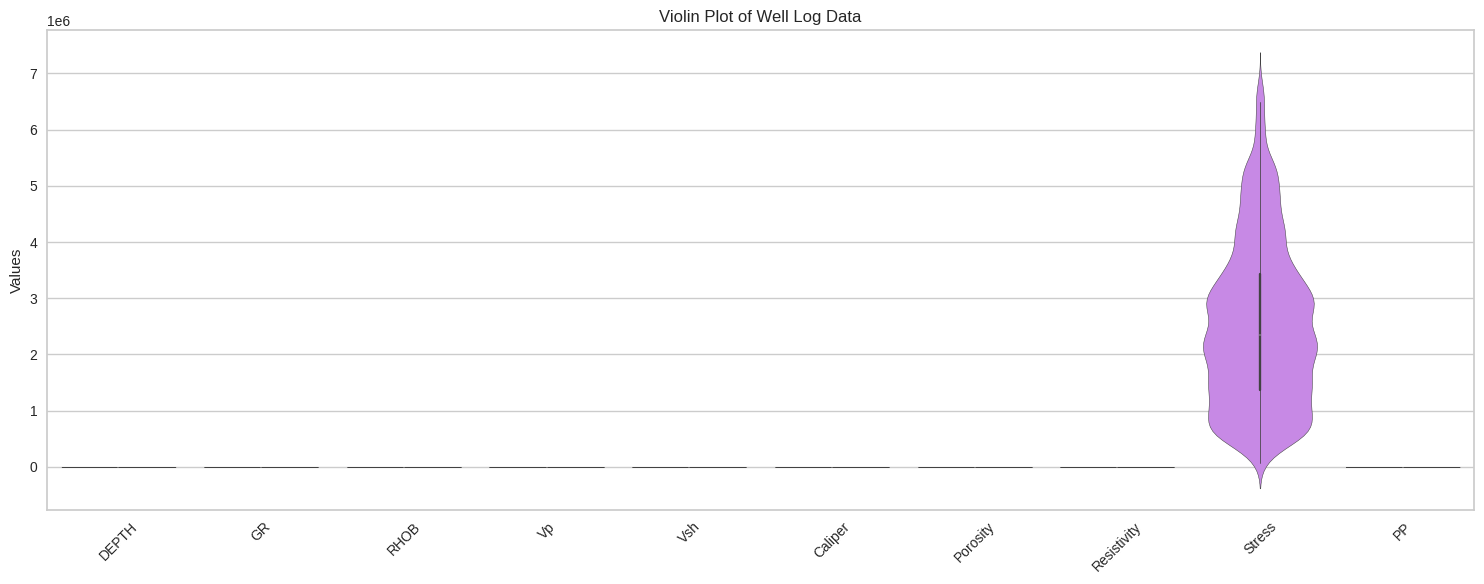

In [47]:
plt.figure(figsize=(15, 6))
sns.violinplot(data=df)
plt.title('Violin Plot of Well Log Data')
plt.xticks(rotation=45)
plt.ylabel('Values')
plt.tight_layout()
plt.show()

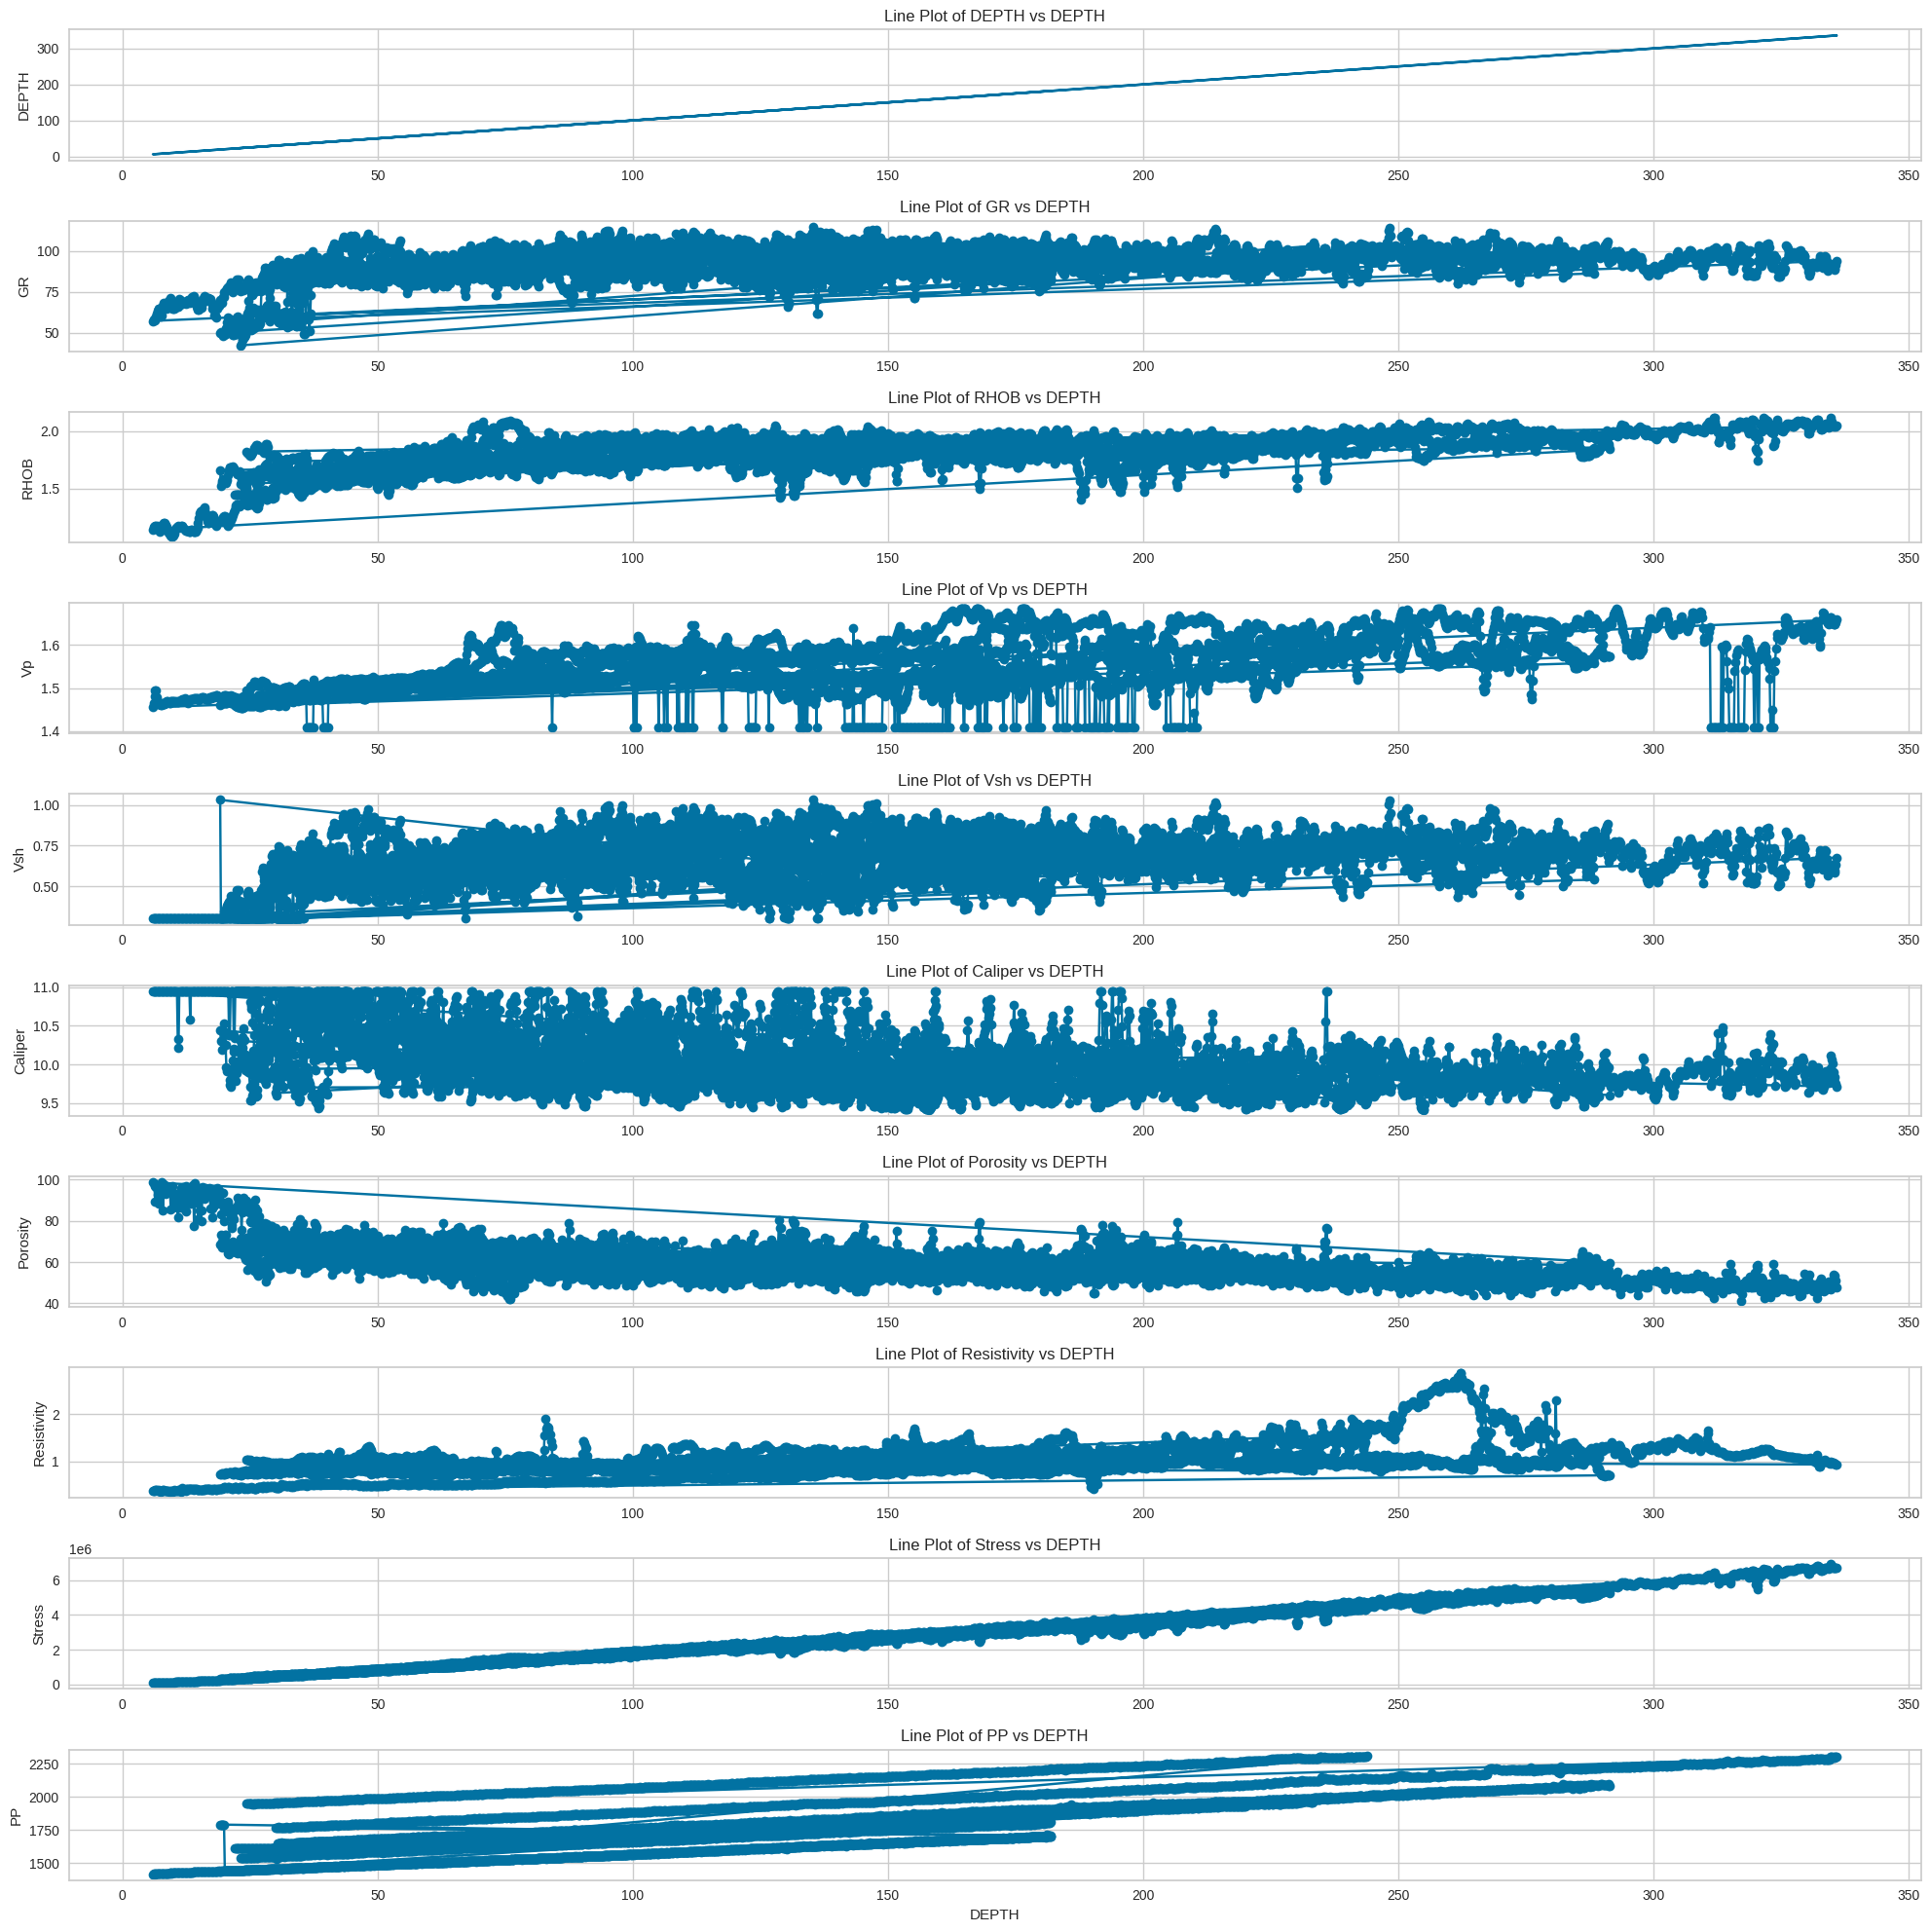

In [48]:
features = df.columns

plt.figure(figsize=(20, 20))

for i, feature in enumerate(features, 1):
    plt.subplot(len(features), 1, i)
    plt.plot(df['DEPTH'], df[feature], marker='o' if feature != 'DEPTH' else '')
    plt.title(f'Line Plot of {feature} vs DEPTH')
    plt.xlabel('DEPTH' if i == len(features) else '')
    plt.ylabel(feature)
    plt.grid(True)

plt.tight_layout()
plt.show()

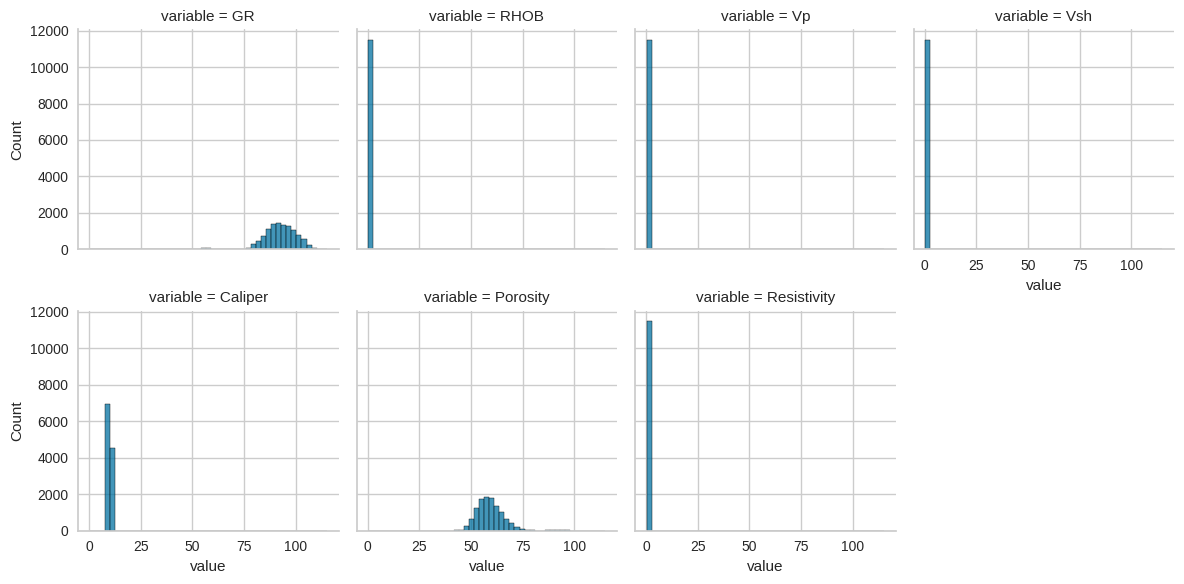

In [49]:
df_long = pd.melt(df, value_vars=['GR', 'RHOB', 'Vp', 'Vsh', 'Caliper', 'Porosity', 'Resistivity'])

sns.displot(data=df_long, x='value', col='variable', col_wrap=4, height=3, aspect=1)
plt.show()

In [50]:
from sklearn.preprocessing import MinMaxScaler

cols = ['GR', 'RHOB', 'Vp', 'Vsh', 'Caliper', 'Porosity', 'Resistivity', 'Stress']

scaler = MinMaxScaler()

df[cols] = scaler.fit_transform(df[cols])

In [51]:
df.head()

,DEPTH,GR,RHOB,Vp,Vsh,Caliper,Porosity,Resistivity,Stress,PP
0,22.0024,0.207822,0.355749,0.192686,0.0,1.0,0.433212,0.171603,0.035873,1609.0
1,22.1548,0.216416,0.355749,0.185408,0.0,1.0,0.433203,0.166428,0.036189,1609.0
2,22.3072,0.231507,0.355749,0.179221,0.0,1.0,0.433192,0.168299,0.036504,1609.0
3,22.4596,0.232990,0.355749,0.175582,0.0,1.0,0.433186,0.164836,0.036820,1609.0
4,22.6120,0.241473,0.355749,0.174491,0.0,1.0,0.433175,0.154287,0.037135,1609.0


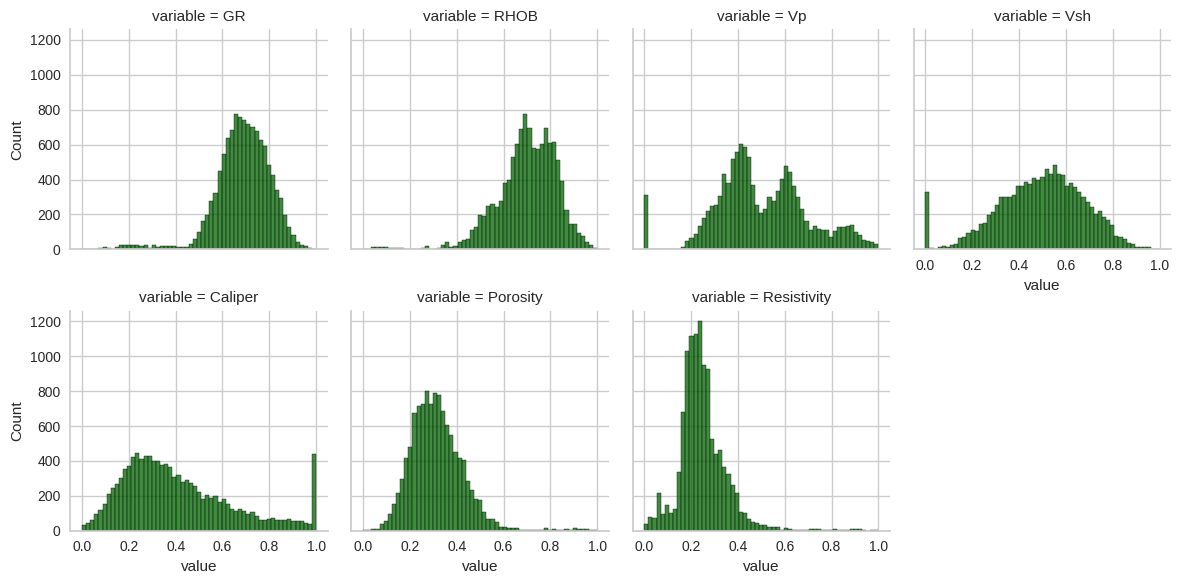

In [52]:
df_long = pd.melt(df, value_vars=['GR', 'RHOB', 'Vp', 'Vsh', 'Caliper', 'Porosity', 'Resistivity'])

sns.displot(data=df_long, x='value', col='variable', col_wrap=4, height=3, aspect=1,color="darkgreen")
plt.show()

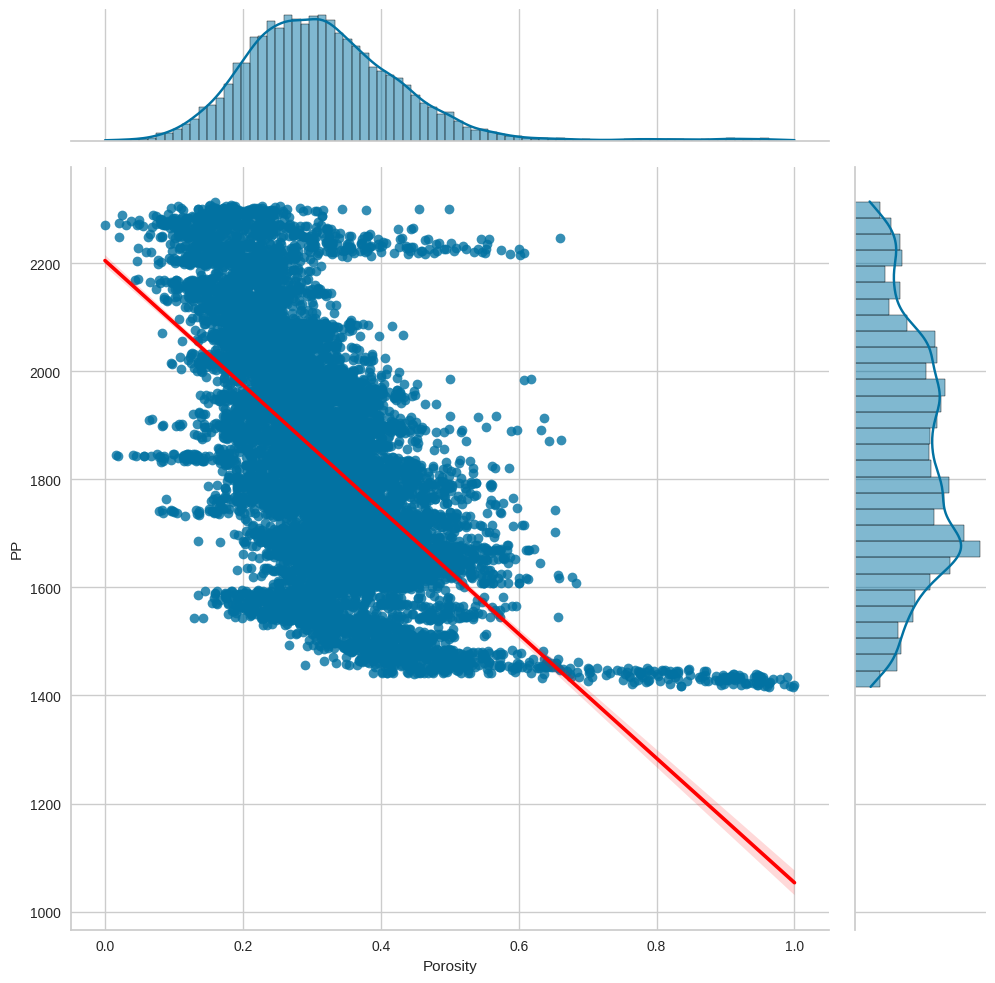

In [53]:
sns.jointplot(x='Porosity', y='PP', data=df, kind='reg', line_kws={"color": "red"},height=10)
plt.show()

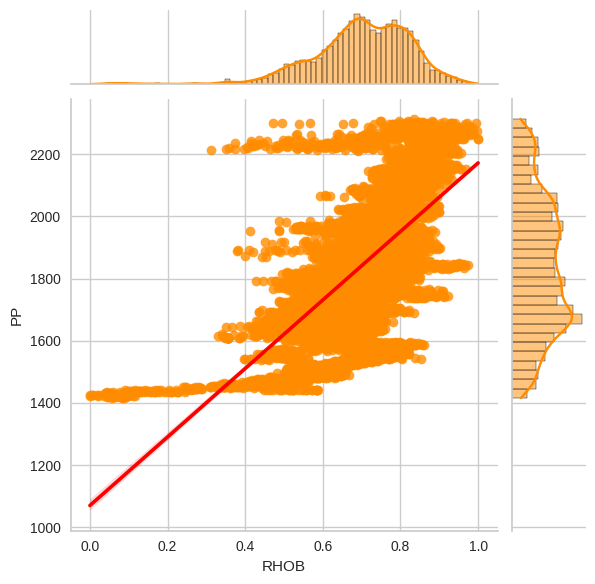

In [54]:
sns.jointplot(x = df['RHOB'], y = df['PP'], kind='reg', line_kws={"color": "red"},color="darkorange")
plt.show()

In [55]:
df.drop(columns=["Vp"],axis=1,inplace=True)

In [56]:
df.head()

,DEPTH,GR,RHOB,Vsh,Caliper,Porosity,Resistivity,Stress,PP
0,22.0024,0.207822,0.355749,0.0,1.0,0.433212,0.171603,0.035873,1609.0
1,22.1548,0.216416,0.355749,0.0,1.0,0.433203,0.166428,0.036189,1609.0
2,22.3072,0.231507,0.355749,0.0,1.0,0.433192,0.168299,0.036504,1609.0
3,22.4596,0.232990,0.355749,0.0,1.0,0.433186,0.164836,0.036820,1609.0
4,22.6120,0.241473,0.355749,0.0,1.0,0.433175,0.154287,0.037135,1609.0


In [57]:
from sklearn.model_selection import train_test_split
X=df.drop(columns=["PP"],axis=1)
y=df["PP"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [58]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (9195, 8)
X_test shape: (2299, 8)
y_train shape: (9195,)
y_test shape: (2299,)


In [59]:
from xgboost import XGBRegressor
model=XGBRegressor(learning_rate=0.1,n_estimators=1000)
model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [60]:
y_pred=model.predict(X_test)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, explained_variance_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
medae = median_absolute_error(y_test, y_pred)
explained_var = explained_variance_score(y_test, y_pred)

n = len(y_test)
p = X_test.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R²): {r2:.4f}")
print(f"Adjusted R-squared: {adjusted_r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}%")
print(f"Median Absolute Error (MedAE): {medae:.4f}")
print(f"Explained Variance Score: {explained_var:.4f}")

Mean Squared Error (MSE): 1737.6429
Root Mean Squared Error (RMSE): 41.6850
Mean Absolute Error (MAE): 26.0805
R-squared (R²): 0.9632
Adjusted R-squared: 0.9631
Mean Absolute Percentage Error (MAPE): 1.4303%
Median Absolute Error (MedAE): 14.6460
Explained Variance Score: 0.9632


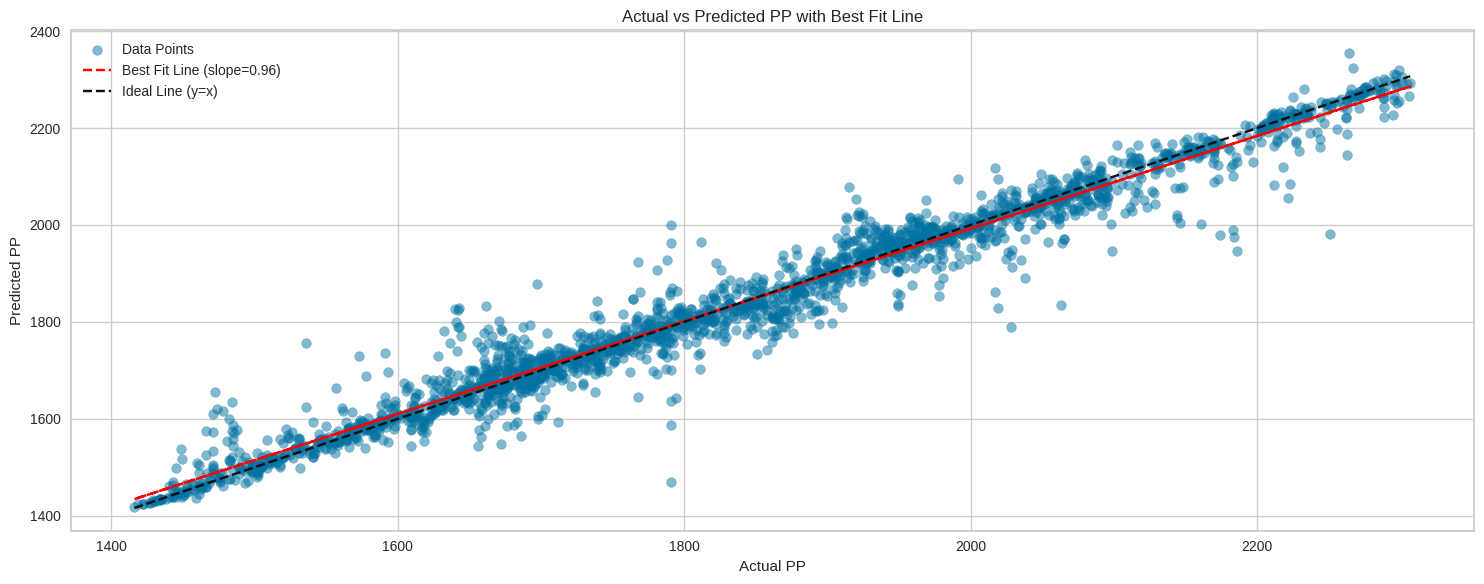

In [61]:
plt.figure(figsize=(15, 6))
plt.scatter(y_test, y_pred, alpha=0.5, label='Data Points')
# Calculate best fit line
z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), color='red', linestyle='--', label=f'Best Fit Line (slope={z[0]:.2f})')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', label='Ideal Line (y=x)')
plt.xlabel('Actual PP')
plt.ylabel('Predicted PP')
plt.title('Actual vs Predicted PP with Best Fit Line')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

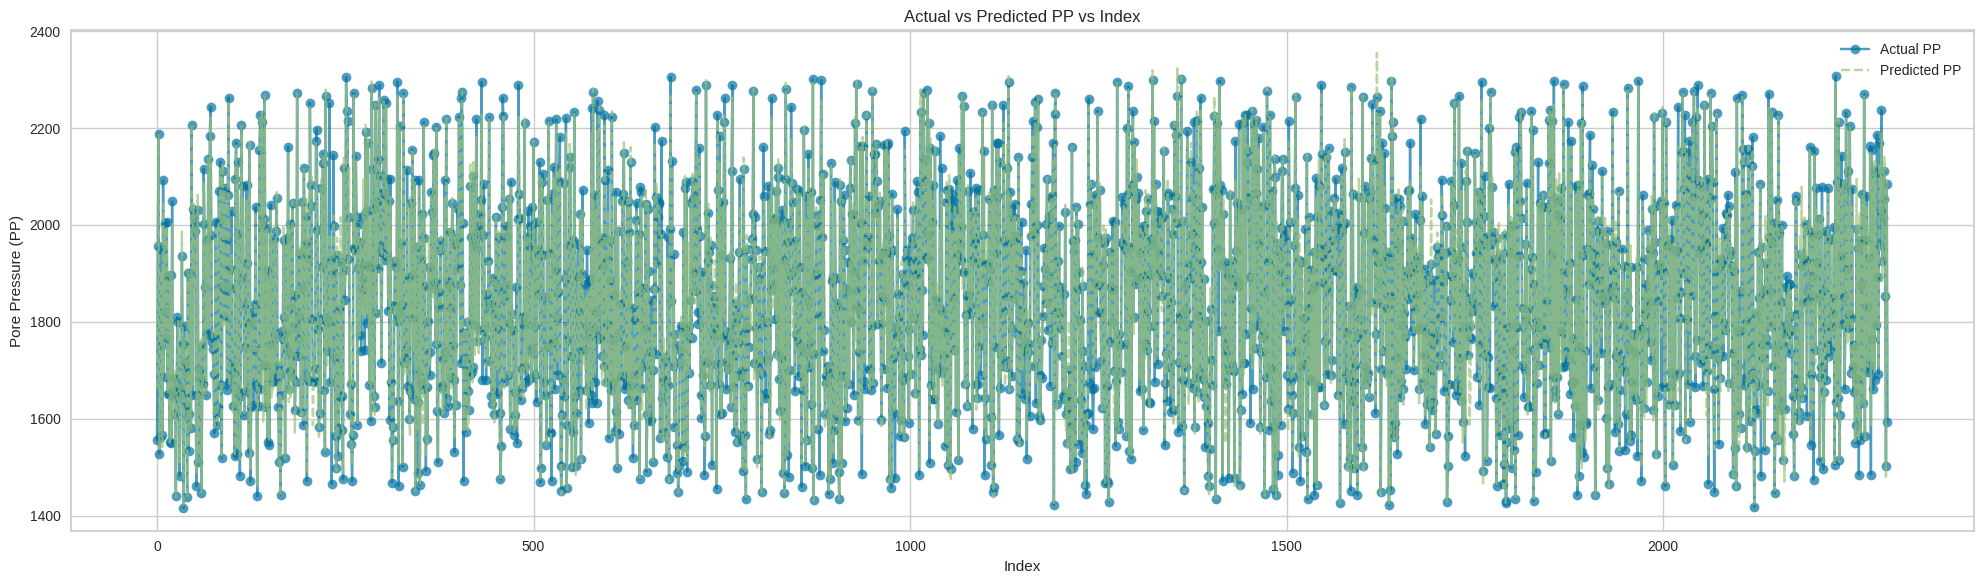

In [62]:
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
y_pred_reset = pd.Series(y_pred, name='Predicted').reset_index(drop=True)

plt.figure(figsize=(20, 6))
plt.plot(y_test_reset.index, y_test_reset, label='Actual PP', marker='o', linestyle='-', alpha=0.7)
plt.plot(y_test_reset.index, y_pred_reset, label='Predicted PP', marker='x', linestyle='--', alpha=0.7)
plt.xlabel('Index')
plt.ylabel('Pore Pressure (PP)')
plt.title('Actual vs Predicted PP vs Index')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [63]:
df.head()

,DEPTH,GR,RHOB,Vsh,Caliper,Porosity,Resistivity,Stress,PP
0,22.0024,0.207822,0.355749,0.0,1.0,0.433212,0.171603,0.035873,1609.0
1,22.1548,0.216416,0.355749,0.0,1.0,0.433203,0.166428,0.036189,1609.0
2,22.3072,0.231507,0.355749,0.0,1.0,0.433192,0.168299,0.036504,1609.0
3,22.4596,0.232990,0.355749,0.0,1.0,0.433186,0.164836,0.036820,1609.0
4,22.6120,0.241473,0.355749,0.0,1.0,0.433175,0.154287,0.037135,1609.0


In [64]:
# import RegressionExperiment and init the class
from pycaret.regression import RegressionExperiment
from pycaret.regression import *
exp = setup(data=df, target='PP')

,Description,Value
0,Session id,6362
1,Target,PP
2,Target type,Regression
3,Original data shape,"(11494, 9)"
4,Transformed data shape,"(11494, 9)"
5,Transformed train set shape,"(8045, 9)"
6,Transformed test set shape,"(3449, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


In [65]:
xg=create_model('xgboost')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,33.0286,2802.5037,52.9387,0.9418,0.0292,0.0182
1,30.0506,2017.9069,44.9211,0.9579,0.0245,0.0164
2,32.2724,2429.3782,49.2887,0.9465,0.0273,0.0178
3,31.4126,2560.4553,50.6009,0.9477,0.0278,0.0172
4,34.3400,2710.9683,52.0670,0.9392,0.0285,0.0189
5,31.4901,2461.7275,49.6158,0.9526,0.0276,0.0173
6,31.8597,2533.6284,50.3352,0.9469,0.0278,0.0176
7,30.1383,2119.3835,46.0368,0.9574,0.0254,0.0166
8,33.0364,2573.8777,50.7334,0.9487,0.0279,0.0182


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [66]:
tune_xg=tune_model(xg)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,33.6816,2579.9836,50.7935,0.9464,0.0283,0.0186
1,30.1760,1916.5419,43.7783,0.9600,0.0238,0.0164
2,34.8788,2594.7959,50.9391,0.9429,0.0280,0.0191
3,33.2255,2425.0532,49.2448,0.9505,0.0272,0.0183
4,34.0645,2516.9512,50.1692,0.9436,0.0275,0.0188
5,31.1850,2391.4282,48.9022,0.9539,0.0273,0.0171
6,33.3230,2454.3093,49.5410,0.9485,0.0274,0.0183
7,30.7701,2126.4866,46.1138,0.9573,0.0255,0.0169
8,33.1943,2391.1909,48.8998,0.9524,0.0270,0.0182


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


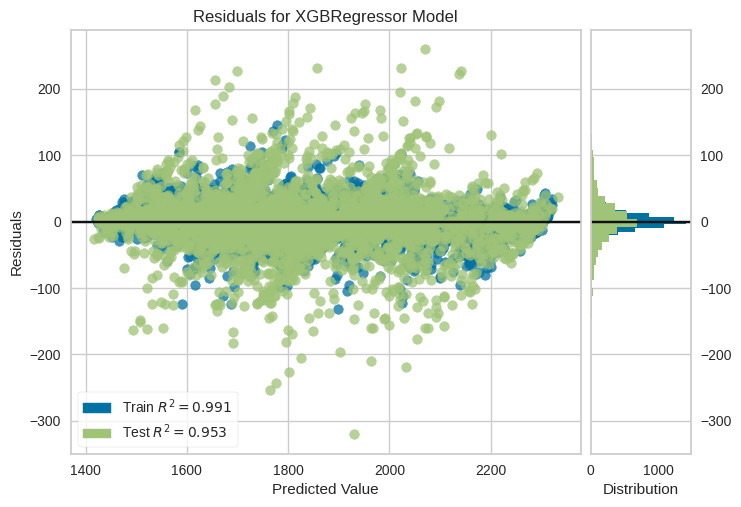

In [67]:
plot_model(xg, plot = 'residuals')

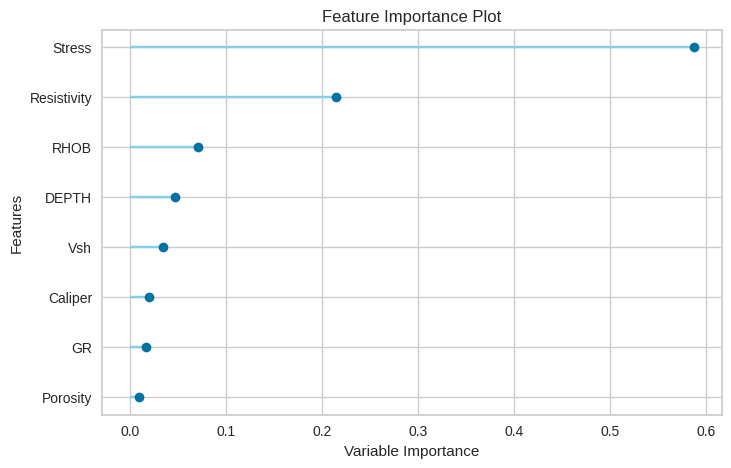

In [68]:
plot_model(xg, plot='feature')


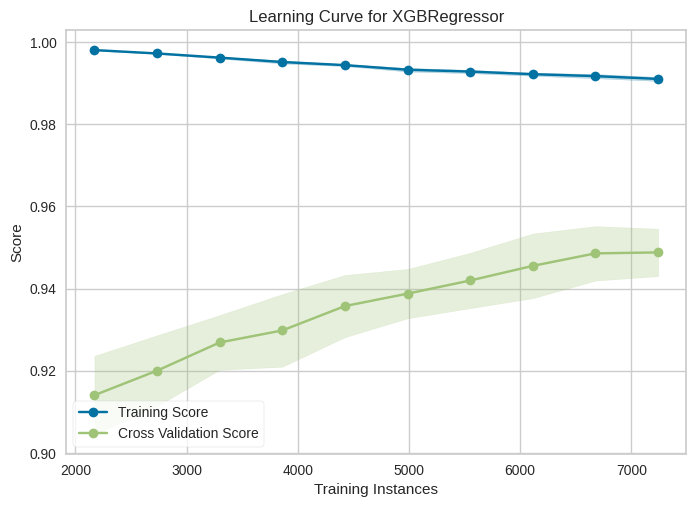

In [69]:
plot_model(xg, plot='learning')

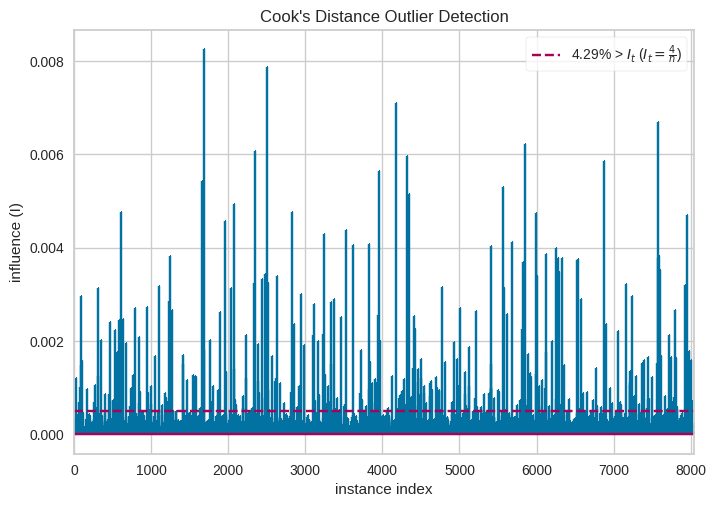

In [70]:
plot_model(xg, plot='cooks')

In [71]:
y_pred= tune_xg.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-10))) * 100
medae = median_absolute_error(y_test, y_pred)
explained_var = explained_variance_score(y_test, y_pred)
n, p = len(y_test), X_test.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Print metrics
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R²): {r2:.4f}")
print(f"Adjusted R-squared: {adjusted_r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}%")
print(f"Median Absolute Error (MedAE): {medae:.4f}")
print(f"Explained Variance Score: {explained_var:.4f}")

Mean Squared Error (MSE): 882.5131
Root Mean Squared Error (RMSE): 29.7071
Mean Absolute Error (MAE): 15.9269
R-squared (R²): 0.9813
Adjusted R-squared: 0.9813
Mean Absolute Percentage Error (MAPE): 0.8724%
Median Absolute Error (MedAE): 7.7018
Explained Variance Score: 0.9814


In [72]:
predict_model(tune_xg)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extreme Gradient Boosting,31.8676,2244.7773,47.3791,0.9531,0.0259,0.0174


,DEPTH,GR,RHOB,Vsh,Caliper,Porosity,Resistivity,Stress,PP,prediction_label
315,70.008400,0.661410,0.615072,0.524339,0.631006,0.539769,0.245442,0.162087,1678.000000,1745.540649
3026,283.075989,0.764200,0.819517,0.604922,0.442611,0.260518,0.253881,0.770355,2085.000000,2051.340576
4959,33.685600,0.646808,0.415556,0.400033,0.940148,0.597034,0.050912,0.063039,1460.000000,1454.314697
2699,233.241196,0.705555,0.789372,0.502567,0.341825,0.217355,0.297429,0.622645,1990.004028,2032.134521
8681,285.895599,0.727211,0.850821,0.540365,0.206921,0.187400,0.291617,0.791346,2211.000000,2186.230225
...,...,...,...,...,...,...,...,...,...,...
3338,72.301598,0.540926,0.610435,0.215232,0.604260,0.393975,0.237202,0.167219,1713.000000,1712.921631
10091,189.095596,0.582139,0.686280,0.412705,0.287420,0.330897,0.263235,0.474166,2220.000000,2117.119629
9511,100.703598,0.693762,0.837585,0.570919,0.391924,0.229010,0.240108,0.270502,2071.000000,2098.334961
2478,199.560806,0.776850,0.719034,0.627001,0.359699,0.379888,0.266261,0.510600,1943.000000,1910.895996


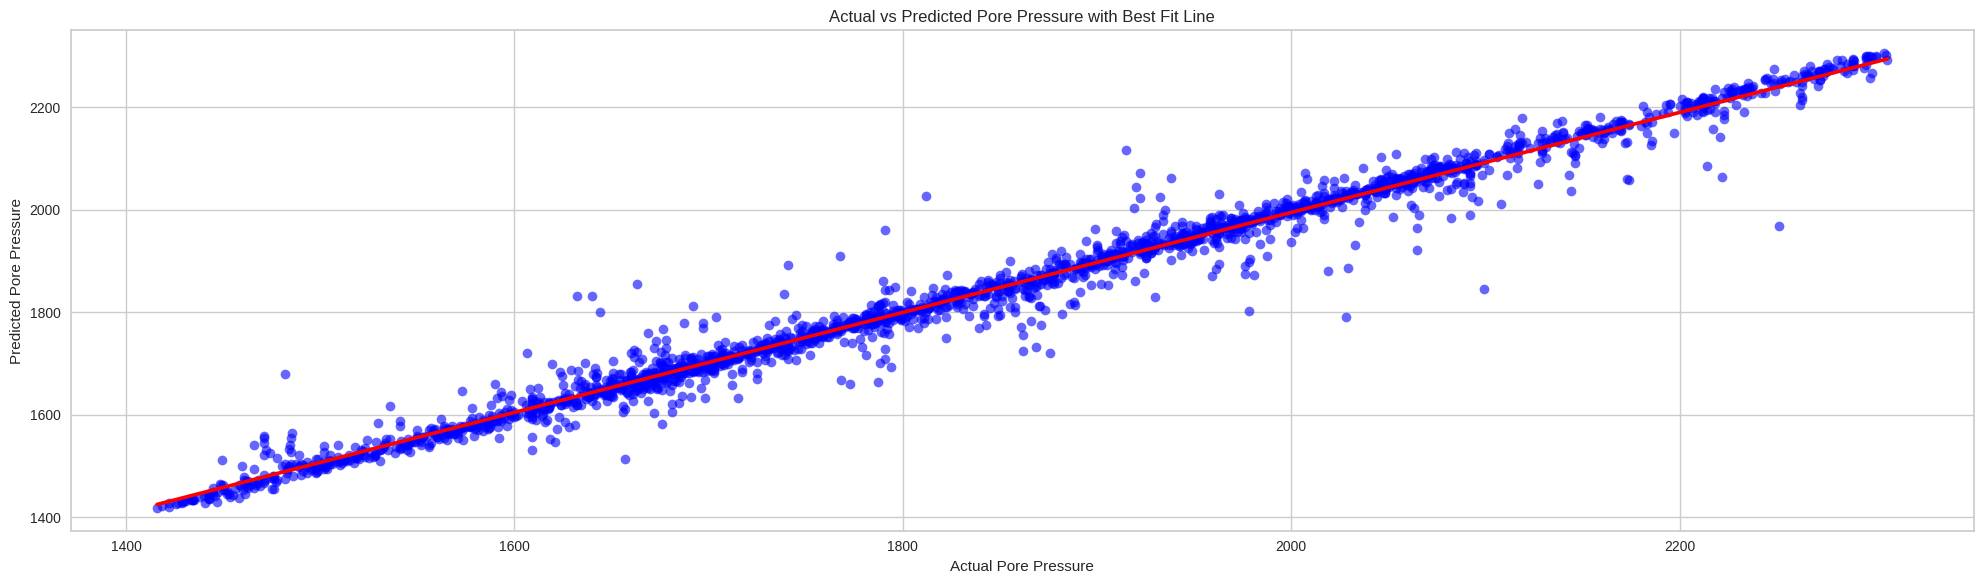

In [73]:

plt.figure(figsize=(20, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.6, 'color':'blue'}, line_kws={'color':'red'})
plt.xlabel('Actual Pore Pressure')
plt.ylabel('Predicted Pore Pressure')
plt.title('Actual vs Predicted Pore Pressure with Best Fit Line')
plt.tight_layout()
plt.show()

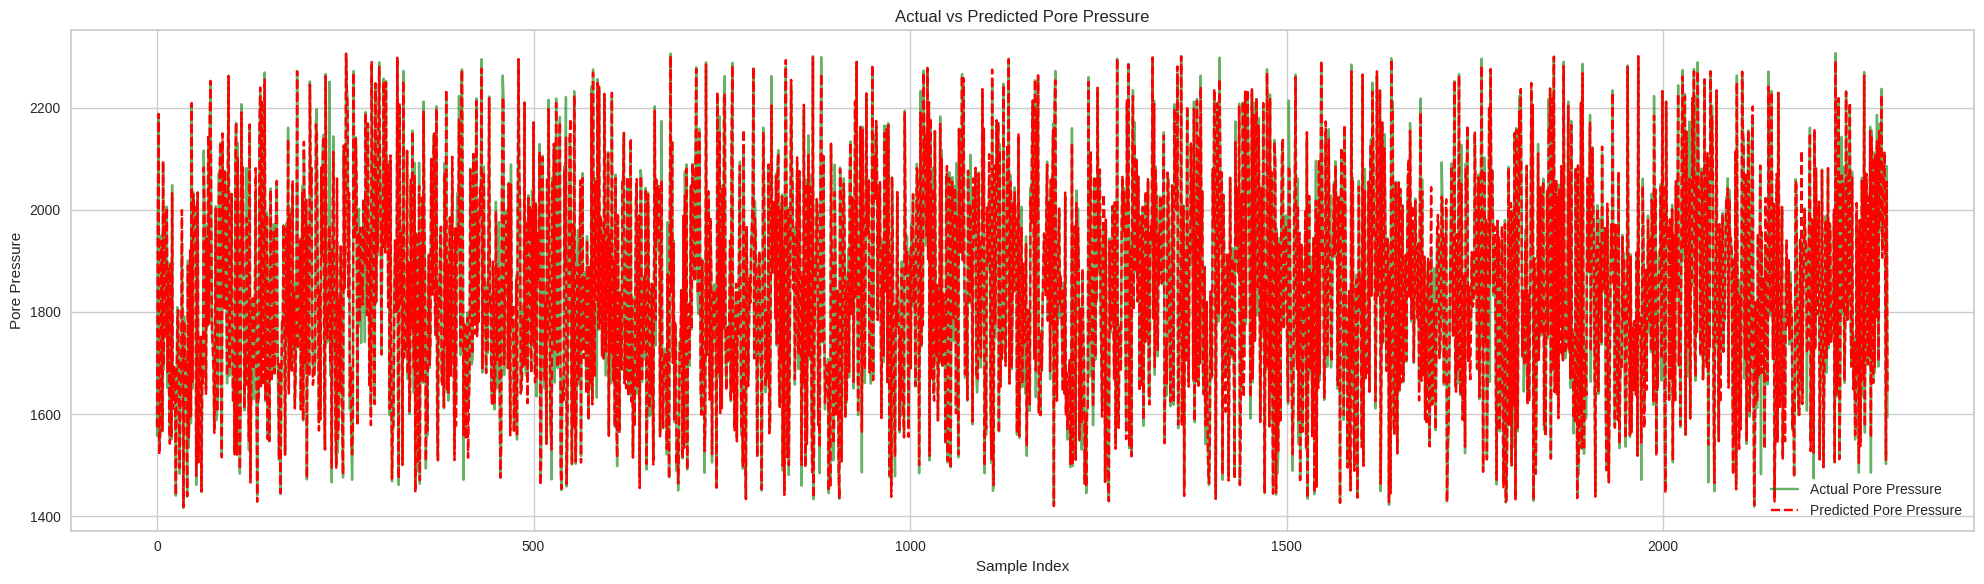

In [74]:
plt.figure(figsize=(20, 6))
index = np.arange(len(y_test))
plt.plot(index, y_test, label='Actual Pore Pressure', color='green', alpha=0.6)
plt.plot(index, y_pred, label='Predicted Pore Pressure', color='red', linestyle='--')
plt.xlabel('Sample Index')
plt.ylabel('Pore Pressure')
plt.title('Actual vs Predicted Pore Pressure')
plt.legend()
plt.tight_layout()
plt.show()

In [75]:
print(exp.plot_model.__doc__)


        This function analyzes the performance of a trained model on holdout set.
        It may require re-training the model in certain cases.


        Example
        --------
        >>> from pycaret.datasets import get_data
        >>> boston = get_data('boston')
        >>> from pycaret.regression import *
        >>> exp_name = setup(data = boston,  target = 'medv')
        >>> lr = create_model('lr')
        >>> plot_model(lr, plot = 'residual')


        estimator: scikit-learn compatible object
            Trained model object


        plot: str, default = 'residual'
            List of available plots (ID - Name):

            * 'pipeline' - Schematic drawing of the preprocessing pipeline
            * 'residuals_interactive' - Interactive Residual plots
            * 'residuals' - Residuals Plot
            * 'error' - Prediction Error Plot
            * 'cooks' - Cooks Distance Plot
            * 'rfe' - Recursive Feat. Selection
            * 'learning' - Learning Curv